# Notebook 01: Data Ingestion, Quality Audit and Exploratory Analysis

## Dataset

**Source:** [Steam Reviews Dataset](https://www.kaggle.com/datasets/luthfim/steam-reviews-dataset), Luthfi Mahendra, Kaggle
**Size:** 434,891 reviews across 48 titles
**Format:** CSV, downloaded via `kagglehub`

Steam reviews carry a binary verdict rather than a star rating: the player either recommends the game or does not. That vote acts as the ground truth label throughout this project, which means no manual annotation is needed to train a classifier.

### Columns

| Column | Description |
|---|---|
| `title` | Name of the game being reviewed |
| `review` | Free text written by the player |
| `recommendation` | Recommended or Not Recommended, the player's verdict |
| `hour_played` | Hours spent in the game at the time of writing |
| `helpful` | Number of other players who marked the review as helpful |
| `funny` | Number of other players who marked the review as funny |
| `is_early_access_review` | Whether the review was written during early access |
| `date_posted` | Date the review was published |

Two columns have no equivalent in a standard product review dataset. `hour_played` says how invested the player was when they formed their opinion, and `helpful` says whether the community found the review worth reading. Both get used later to segment feedback rather than treating every review as equally weighted.

## Project overview

An end-to-end NLP analysis of Steam user reviews covering top-selling video games. The goal is to measure what players actually say, how reliably a model can tell praise from complaint, and which recurring themes drive satisfaction or frustration across major titles.

The pipeline runs across six notebooks:

1. **Notebook 01 (current):** ingestion, quality audit and exploratory analysis
2. **Notebook 02:** text cleaning, boilerplate removal, deduplication and feature engineering
3. **Notebook 03:** baseline sentiment with a pretrained transformer, no training
4. **Notebook 04:** fine-tuned DistilBERT, benchmarked against TF-IDF with logistic regression and against the pretrained baseline
5. **Notebook 05:** per-game topic modelling with BERTopic
6. **Notebook 06:** aspect-based sentiment extraction using an LLM with structured output

## Scope of this notebook

Before any text gets transformed or any model gets trained, this notebook establishes what the dataset actually contains: its integrity, its distributions, and the constraints they place on everything downstream.

**Per-game distribution.** How review volume concentrates across titles, which determines what per-game topic modelling can support in Notebook 05.

**Data quality audit.** Exact row duplicates, missing text, repeated review strings and platform boilerplate.

**Univariate analysis.** Class balance in the target, review length and player engagement.

**Bivariate analysis.** What relates to whether a player recommends a game, tested with Mann-Whitney U and reported with rank-biserial effect sizes rather than p-values alone, since a corpus this size makes almost any difference statistically significant.

## 1. Setup and data loading

In [1]:
import os
from pathlib import Path
from google.colab import drive
from IPython.display import Markdown, display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mount Google Drive
drive.mount("/content/drive")

# 2. Paths
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Projets/steam_reviews")
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_PATH = DATA_DIR / "raw" / "steam_reviews.csv"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 3. Plotting style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 100

# 4. Load dataset
raw_df = pd.read_csv(RAW_DATA_PATH)

display(
    Markdown(
        f"**Loaded** `{RAW_DATA_PATH.name}` "
        f"(`{RAW_DATA_PATH.stat().st_size / 1e6:.2f} MB`) \n "
        f"`{raw_df.shape[0]:,}` rows x `{raw_df.shape[1]}` columns"
    )
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Loaded** `steam_reviews.csv` (`120.72 MB`) 
 `434,891` rows x `8` columns

File loaded into `raw_df`. Quick look at the first rows to confirm the columns match what we expect (`recommendation`, `review`, `hour_played`, `word_count`, `helpful`, etc.).

In [2]:
raw_df.head(5)

,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title
0,2019-02-10,2,4,578,False,Recommended,&gt Played as German Reich&gt Declare war on B...,Expansion - Hearts of Iron IV: Man the Guns
1,2019-02-10,0,0,184,False,Recommended,yes.,Expansion - Hearts of Iron IV: Man the Guns
2,2019-02-07,0,0,892,False,Recommended,Very good game although a bit overpriced in my...,Expansion - Hearts of Iron IV: Man the Guns
3,2018-06-14,126,1086,676,False,Recommended,Out of all the reviews I wrote This one is pro...,Dead by Daylight
4,2017-06-20,85,2139,612,False,Recommended,Disclaimer I survivor main. I play games for f...,Dead by Daylight


Columns look consistent with the dataset documentation. Moving to a data quality pass before any actual analysis.

# 2. Data quality

A preliminary audit of raw duplicates and missing values is performed to evaluate data integrity before downstream feature engineering.

In [3]:
# 1. Duplicate rows
n_duplicates = raw_df.duplicated().sum()

# 2. Missing values per column
missing_summary = (
    raw_df.isna().sum()
    .to_frame("Missing Count")
    .assign(**{"Missing %": lambda x: (x["Missing Count"] / len(raw_df) * 100).round(2)})
    .sort_values("Missing Count", ascending=False)
)

display(
    Markdown(
        f"**Duplicate rows:** `{n_duplicates:,}` ({n_duplicates / len(raw_df):.2%})"
    )
)
display(missing_summary)


**Duplicate rows:** `0` (0.00%)

,Missing Count,Missing %
review,1516,0.35
date_posted,0,0.00
helpful,0,0.00
funny,0,0.00
hour_played,0,0.00
is_early_access_review,0,0.00
recommendation,0,0.00
title,0,0.00


### Data Quality Audit

* **Exact Duplicate Rows:** 0 rows (0.00% of the corpus).
* **Missing Text Values:** The `review` column contains 1,516 missing entries (0.35% of the total dataset). All other metadata columns (`date_posted`, `helpful`, `funny`, `hour_played`, `is_early_access_review`, `recommendation`, `title`) are fully populated with zero missing values.

#### Action Item for Notebook 02
The 1,516 rows missing textual content provide no signal for sentiment classification or topic modeling. These record entries will be formally dropped during the initial cleaning phase of Notebook 02.


## 2.1 Repeated review text

Identical rows are one thing, identical text is another. The same review appearing many times inflates whatever topic it belongs to, and if it lands on both sides of a train/test split, the model gets to see the answer during training.

In [4]:
n_row_duplicates = raw_df.duplicated().sum()
n_text_duplicates = raw_df["review"].duplicated().sum()

display(
    Markdown(
        f"Exact row duplicates: `{n_row_duplicates:,}` ({n_row_duplicates / len(raw_df):.2%})  \n"
        f"Repeated review texts: `{n_text_duplicates:,}` ({n_text_duplicates / len(raw_df):.2%})"
    )
)

if "word_count" not in raw_df.columns:
    raw_df["word_count"] = raw_df["review"].fillna("").str.split().str.len()

top_repeated = raw_df["review"].value_counts().head(10).reset_index()
top_repeated.columns = ["Review text", "Occurrences"]
top_repeated["Word count"] = top_repeated["Review text"].str.split().str.len()
top_repeated = top_repeated[["Review text", "Occurrences", "Word count"]]

pd.set_option("display.max_colwidth", 200)
display(top_repeated)

Exact row duplicates: `0` (0.00%)  
Repeated review texts: `54,979` (12.64%)

,Review text,Occurrences,Word count
0,good game,1443,2
1,good,1283,1
2,.,883,1
3,10/10,773,1
4,Good game,748,2
5,nice game,740,2
6,nice,649,1
7,Great game,581,2
8,great game,579,2
9,Good,530,1


* **Exact Row Duplicates:** 0 (0.00%)
* **Repeated Review Texts:** 54,979 (12.64%)

54,979 rows, 12.64% of the corpus, carry text that appears somewhere else. The ten most frequent are all short praise: "good game" 1,443 times, "10/10" 773 times, down to a single full stop 883 times. That is what hundreds of players writing the same obvious thing looks like, not a problem to fix.

### Filtering logic: Short vs. long text repetitions

Casing counts as a difference here, so "good game" and "Good game" show up as separate entries. Lowercasing in Notebook 02 will merge them.

Short repetition is expected in user-generated content. Long repetition is not, since nobody writes the same forty-word review as someone else by chance. Filtering on text length separates the two, and reading what comes out is the only way to inspect what is actually in the corpus.

In [5]:
MIN_WORDS = 5

pd.set_option("display.max_colwidth", None)

text_counts = raw_df["review"].value_counts()

long_repeated = (
    raw_df.drop_duplicates(subset=["review"])
    .assign(occurrences=lambda x: x["review"].map(text_counts))
    .query("word_count >= @MIN_WORDS and occurrences > 1")
    .sort_values("occurrences", ascending=False)
)

print(f"{len(long_repeated):,} distinct texts of {MIN_WORDS}+ words appear more than once")
print(f"covering {long_repeated['occurrences'].sum():,} rows in total")

display(long_repeated[["review", "word_count", "occurrences"]].head(30))

1,645 distinct texts of 5+ words appear more than once
covering 6,639.0 rows in total


,review,word_count,occurrences
6141,Product received for free. good game,6,167.0
7440,Product received for free. good,5,134.0
601,Product received for free. nice game,6,121.0
215114,"Bluehole Chinese Official indulges Chinese famous game streamer ""55kai"" Lu Benwei with repeated cheating behaviors on Douyu Streaming Platform which makes a extremely immoral example for teenagers and all players and lovers of PUBG. We protest against Cheating and Official's ignorance!We Need Justice and Fairness",45,120.0
941,Product received for free. Good game,6,86.0
5641,Product received for free. nice,5,85.0
4561,Product received for free. Nice game,6,79.0
3368,Product received for free. Good,5,74.0
114558,Dont buy this Take two interactive is screwing it over with the online gameplay and anti modding policys.,18,54.0
216927,"Bluehole Chinese Official indulges Chinese famous game streamer ""55kai"" Lu Benwei with repeated cheating behaviors on Douyu Streaming Platform which makes a extremely immoral example for teenagers and all players and lovers of PUBG. We protest against Cheating and Official's ignorance!We Need Justice and Fairness 蓝洞中国官方放任中国知名游戏主播 55开 卢本伟在斗鱼直播平台上的多次开挂行为 为青少年和游戏爱好者作了极其恶劣的不道德示范 我们抗议作弊行为和官方的漠然不作为 我们需要公平和公正",51,51.0


### What the repeated texts contain

1,645 distinct texts of five words or more appear more than once, covering 6,639 rows. Four different categories turn up in the inspection, each needing its own specific treatment:

* **Platform boilerplate:** Steam prepends *"Product received for free."* when a player got the game through a giveaway or a review key. It accounts for most entries in this table. The player wrote "good game", the platform wrote the rest. Stripping the prefix collapses these back into the short generic praise they belong with.
* **Review bombing:** Two campaigns show up clearly. One targets PUBG: a 45-word protest about Bluehole tolerating a streamer caught cheating, posted 120 times in English and 51 more in a bilingual version. The other targets GTA V after Take-Two shut down the OpenIV modding tool in 2017, spread across several wordings ("On behalf of the OpenIV team" 48 times, a call to boycott 54 times, a petition link 32 times). These are coordinated actions rather than independent opinions, and counting them once each is more honest than counting them 120 times.

* **Noise:** One entry is 89 invisible Hangul filler characters repeated 30 times, which `word_count` reads as an 89-word review. Another is ASCII art. Neither carries an opinion, and both show that raw word count is a poor proxy for how much a review actually says.
* **Genuine repetition:** Phrases such as "Fun to play with friends" appearing 27 times represent 27 people who felt the same way in the same plain words.

#### ⚠️ Pipeline Limitation Note
The GTA V campaign exists in several wordings, so a filter matching identical text only catches part of it. Downstream cleaning in Notebook 02 will handle deduplication and boilerplate stripping prior to feature engineering.

# 3. Univariate analysis
## 3.1. Recommendation distribution

Steam gives players a binary choice, Recommended or Not Recommended. This is the target for fine-tuning in, so its balance matters early.

### Target imbalance considerations

Understanding the proportion of positive versus negative reviews is essential for evaluating whether performance metrics like accuracy will be misleading, and for determining if class-weighting or specialized sampling strategies will be required during model training.

,Recommendation,Review Count,Percentage
0,Recommended,303593,69.81
1,Not Recommended,131298,30.19


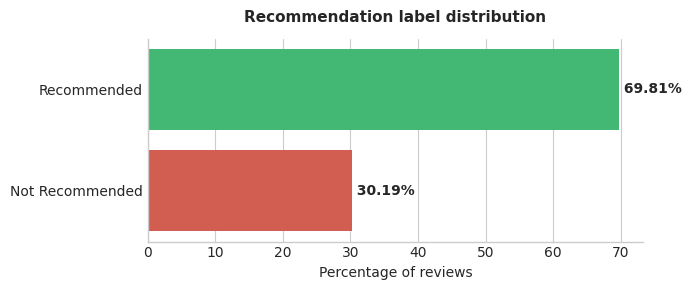

In [6]:
rec_summary = raw_df["recommendation"].value_counts().reset_index()
rec_summary.columns = ["Recommendation", "Review Count"]
rec_summary["Percentage"] = ((rec_summary["Review Count"] / len(raw_df)) * 100).round(2)

display(rec_summary)

plt.figure(figsize=(7, 3))
palette = {"Recommended": "#2ecc71", "Not Recommended": "#e74c3c"}
ax = sns.barplot(
    data=rec_summary, x="Percentage", y="Recommendation",
    hue="Recommendation", palette=palette, legend=False, orient="h",
)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f" {width:.2f}%", (width, p.get_y() + p.get_height() / 2.0),
                ha="left", va="center", fontsize=10, fontweight="bold")

plt.title("Recommendation label distribution", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Percentage of reviews")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()


### Target balance summary

| Recommendation | Review Count | Percentage |
| :--- | :--- | :--- |
| **Recommended** | 303,593 | 69.81% |
| **Not Recommended** | 131,298 | 30.19% |

The corpus displays a clear ~70/30 split in favor of positive recommendations (303,593 Recommended vs. 131,298 Not Recommended).

### What this means for the models

A model that always answers "Recommended" would already reach 69.81% accuracy. That is the floor any classifier has to clear, and it makes accuracy a poor headline metric on its own.

Notebooks 03 and 04 therefore report macro F1, along with precision and recall on the minority class, *Not Recommended*. That is the class that matters here.

## 3.2 Review length


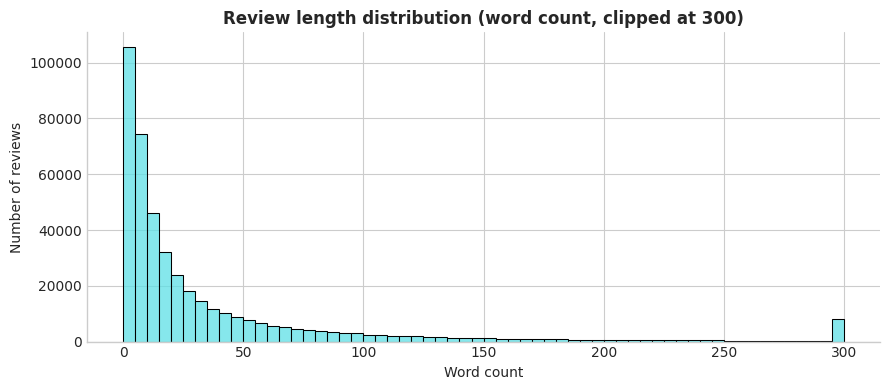

In [7]:
plt.figure(figsize=(9, 4))
sns.histplot(raw_df["word_count"].clip(upper=300), bins=60, color="#5DE0E6")
plt.title("Review length distribution (word count, clipped at 300)", fontsize=12, fontweight="bold")
plt.xlabel("Word count")
plt.ylabel("Number of reviews")
sns.despine()
plt.tight_layout()
plt.show()

Right-skewed, most reviews are a handful of words with a long tail of detailed ones. Worth revisiting split by recommendation in section 4.2.

#### ⚠️ Caveat on raw word count metrics

One caveat from the repeated-text reading above: word count treats invisible filler characters and ASCII art as words, so the tail is not entirely made of substantial reviews. Text normalization in Notebook 02 will address this before downstream modeling.

## 3.3 Games covered

The dataset is billed as covering Steam's best-selling games, which says nothing about how evenly.

,Game,Review Count,Percentage
0,PLAYERUNKNOWN'S BATTLEGROUNDS,145685,33.50
1,Grand Theft Auto V,99956,22.98
2,Rust,71088,16.35
3,Rocket League®,67907,15.61
4,Dead by Daylight,22221,5.11
5,MONSTER HUNTER: WORLD,18412,4.23
6,ASTRONEER,2661,0.61
7,The Elder Scrolls V: Skyrim Special Edition,1473,0.34
8,RESIDENT EVIL 2 / BIOHAZARD RE:2,1385,0.32
9,Sid Meier’s Civilization® VI,522,0.12


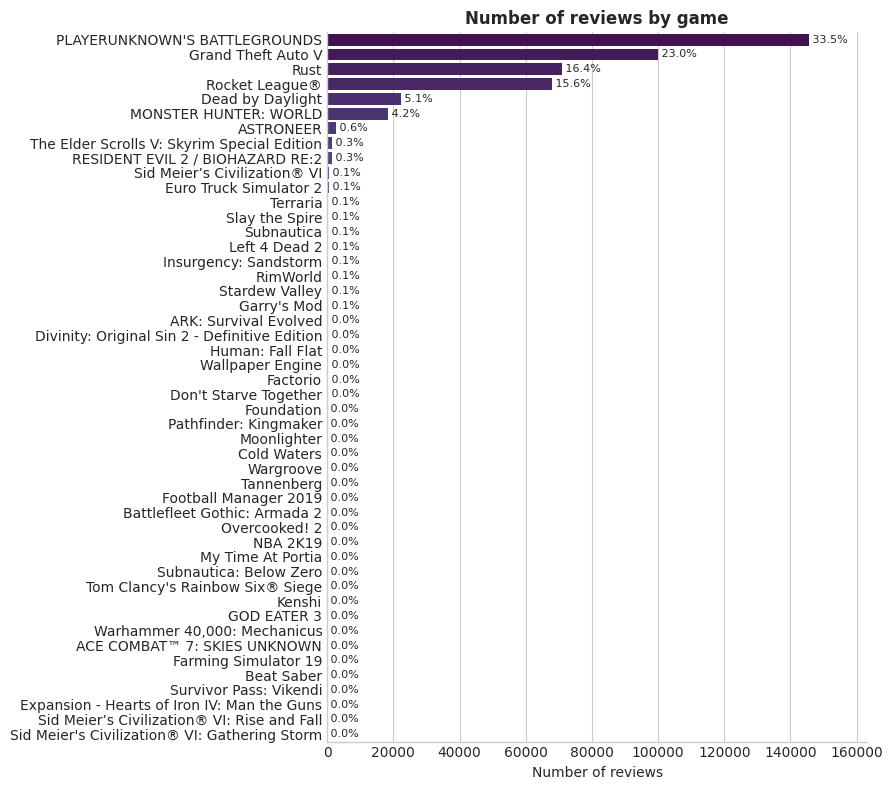

In [8]:
game_counts = raw_df["title"].value_counts().reset_index()
game_counts.columns = ["Game", "Review Count"]
game_counts["Percentage"] = (game_counts["Review Count"] / len(raw_df) * 100).round(2)

display(game_counts)

plt.figure(figsize=(9, 8))
ax = sns.barplot(
    data=game_counts, x="Review Count", y="Game",
    hue="Game", legend=False, palette="viridis",
)
for i, row in game_counts.iterrows():
    ax.annotate(
        f" {row['Percentage']:.1f}%",
        (row["Review Count"], i),
        ha="left", va="center", fontsize=8,
    )

plt.title("Number of reviews by game", fontsize=12, fontweight="bold")
plt.xlabel("Number of reviews")
plt.ylabel("")
plt.xlim(0, game_counts["Review Count"].max() * 1.12)
sns.despine()
plt.tight_layout()
plt.show()

### Review counts per game

Review counts across titles follow an extreme long tail.

The top 4 titles carry roughly 88% of the corpus on their own: *PLAYERUNKNOWN'S BATTLEGROUNDS* at 33.5%, *Grand Theft Auto V* at 23.0%, *Rust* at 16.4% and *Rocket League* at 15.6%. Adding *Dead by Daylight* and *MONSTER HUNTER: WORLD* brings the top 6 to over 98%, with at least 18,412 reviews each. Everything below that drops off fast: 23 games have only 10 reviews, and 4 expansions have 3.

This sets two constraints for the notebooks that follow.

The sentiment models in notebooks 03 and 04 are trained on a corpus dominated by competitive online multiplayer titles. They will learn the vocabulary that comes with it: anti-cheat, server stability, microtransactions. That is worth remembering when reading their results.

Per-game topic modelling in notebook 05 is restricted to the top 6 games. Below 500 reviews a per-game topic model is not reliable, and a recommendation rate computed on 10 reviews means nothing.

## 3.4 Playtime distribution

`hour_played` records how long a player had spent in the game when they wrote the review. It matters because a complaint from someone with half an hour of playtime, likely a launch bug or a bad first impression, does not mean the same thing as one from a player with several hundred hours, more likely late-game fatigue or a reaction to an update.


Notebook 05 uses this distinction to segment topics by how invested the player was, making the baseline playtime distribution essential to inspect during initial EDA.

,hour_played
count,434891.0
mean,364.1
std,546.0
min,0.0
25%,62.0
50%,190.0
75%,450.0
max,31962.0


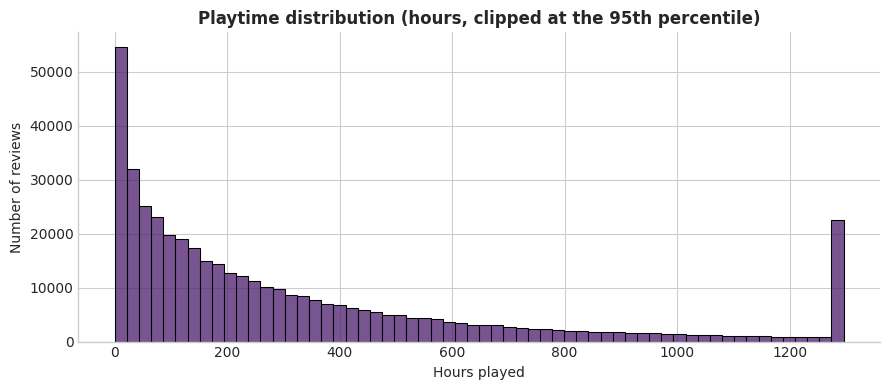

In [9]:
display(raw_df["hour_played"].describe().round(1))

plt.figure(figsize=(9, 4))
sns.histplot(
    raw_df["hour_played"].clip(upper=raw_df["hour_played"].quantile(0.95)),
    bins=60, color="#4B1C6B",
)
plt.title("Playtime distribution (hours, clipped at the 95th percentile)", fontsize=12, fontweight="bold")
plt.xlabel("Hours played")
plt.ylabel("Number of reviews")
sns.despine()
plt.tight_layout()
plt.show()


Heavily right-skewed, as expected. Median playtime stands at 190 hours, while extreme outliers reach tens of thousands of hours.

Playtime is therefore turned into tiers (casual, regular, hardcore) rather than used raw.

## 3.5 Playtime

`hour_played` records how long a player had spent in the game when they wrote the review. It matters because a complaint from someone with half an hour of playtime, likely a launch bug or a bad first impression, does not mean the same thing as one from a player with several hundred hours, more likely late-game fatigue or a reaction to an update.

Notebook 05 uses this to segment topics by how invested the player was.

Reviews carrying the free-product notice: `15,875` (3.65% of the corpus)

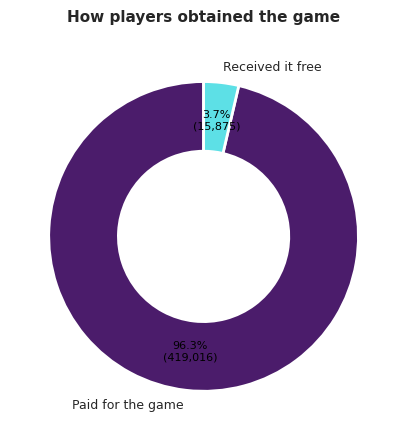

In [10]:
free_mask = raw_df["review"].str.contains("product received for free", case=False, na=False)

counts = [(~free_mask).sum(), free_mask.sum()]
labels = ["Paid for the game", "Received it free"]

display(
    Markdown(
        f"Reviews carrying the free-product notice: `{free_mask.sum():,}` "
        f"({free_mask.mean():.2%} of the corpus)"
    )
)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=labels,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * sum(counts) / 100)):,})",
    colors=["#4B1C6B", "#5DE0E6"],
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 9},
)
for autotext in autotexts:
    autotext.set_color("black")
    autotext.set_fontsize(8)

ax.set_title("How players obtained the game", fontsize=11, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### Promotional review metadata summary

* **Reviews carrying the free-product notice:** 15,875 (3.65% of the corpus)

#### Key Takeaway for Feature Engineering
While free-product reviews make up a small proportion of the overall dataset (3.65%), the system-generated boilerplate text associated with them artificially inflates review word counts. Stripping this prefix in Notebook 02 will ensure accurate token length and sentiment signal across playtime segments.

# 4. Bivariate analysis

Four questions about what relates to whether a player recommends a game:

1. Do complaints come from players who quit almost immediately, or from players who accumulated hundreds of hours before turning on the game?
2. Are complaints longer and more detailed than praise?
3. Do the reviews the community finds helpful skew towards one side?
4. Does receiving the game for free shift the verdict?

## 4.1 Recommendation vs playtime

`hour_played` is heavily skewed, so Mann-Whitney U is used rather than a t-test. With close to 400K rows the test will be significant almost by construction, so the rank-biserial effect size is what actually says whether the difference means anything.

,count,mean,std,min,25%,50%,75%,max
recommendation,,,,,,,,
Not Recommended,131298.0,295.4,438.6,0.0,43.0,153.0,380.0,12113.0
Recommended,303593.0,393.9,583.8,0.0,71.0,207.0,484.0,31962.0


**U Mann-Whitney U statistic:** `22,553,230,776`  
**p-value:** `0`  
**Rank-biserial effect size:** `-0.1316` (small)

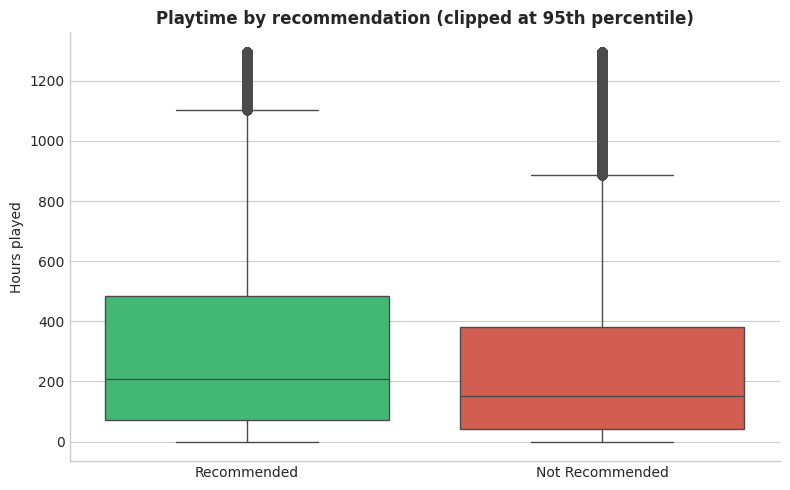

In [11]:
from scipy.stats import mannwhitneyu

playtime_by_rec = raw_df.groupby("recommendation")["hour_played"].describe().round(1)
display(playtime_by_rec)

rec_group = raw_df.loc[raw_df["recommendation"] == "Recommended", "hour_played"].dropna()
not_rec_group = raw_df.loc[raw_df["recommendation"] == "Not Recommended", "hour_played"].dropna()

stat, p_value = mannwhitneyu(rec_group, not_rec_group, alternative="two-sided")
n1, n2 = len(rec_group), len(not_rec_group)
rank_biserial = 1 - (2 * stat) / (n1 * n2)

display(
    Markdown(
        f"**U Mann-Whitney U statistic:** `{stat:,.0f}`  \n"
        f"**p-value:** `{p_value:.4g}`  \n"
        f"**Rank-biserial effect size:** `{rank_biserial:.4f}` "
        f"({'negligible' if abs(rank_biserial) < 0.1 else 'small' if abs(rank_biserial) < 0.3 else 'moderate' if abs(rank_biserial) < 0.5 else 'large'})"
    )
)

plt.figure(figsize=(8, 5))
plot_df = raw_df.copy()
plot_df["hour_played_clipped"] = plot_df["hour_played"].clip(upper=plot_df["hour_played"].quantile(0.95))

ax = sns.boxplot(
    data=plot_df, x="recommendation", y="hour_played_clipped",
    hue="recommendation", palette=palette, legend=False,
)
ax.set_title("Playtime by recommendation (clipped at 95th percentile)", fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Hours played")
sns.despine()
plt.tight_layout()
plt.show()


#### Takeaways
Players who recommend a game tend to have higher overall playtime (median 207 hours vs 153 hours for negative reviews). However, the small effect size ($r = -0.1316$) indicates that playtime alone is not a strong single predictor of recommendation status.

## 4.2 Recommendation vs review length

The same non-parametric approach is applied to `word_count` to evaluate whether negative reviews contain more detailed feedback than positive ones. Given the extreme skewness of text lengths, the Mann-Whitney U test and rank-biserial effect size are used.

,count,mean,std,min,25%,50%,75%,max
recommendation,,,,,,,,
Not Recommended,131298.0,54.4,101.8,0.0,7.0,21.0,59.0,2895.0
Recommended,303593.0,34.4,78.9,0.0,4.0,11.0,31.0,7984.0


**Mann-Whitney U statistic:** `15,543,909,094`  
**p-value:** `0`  
**Rank-biserial effect size:** `0.2201` (small)

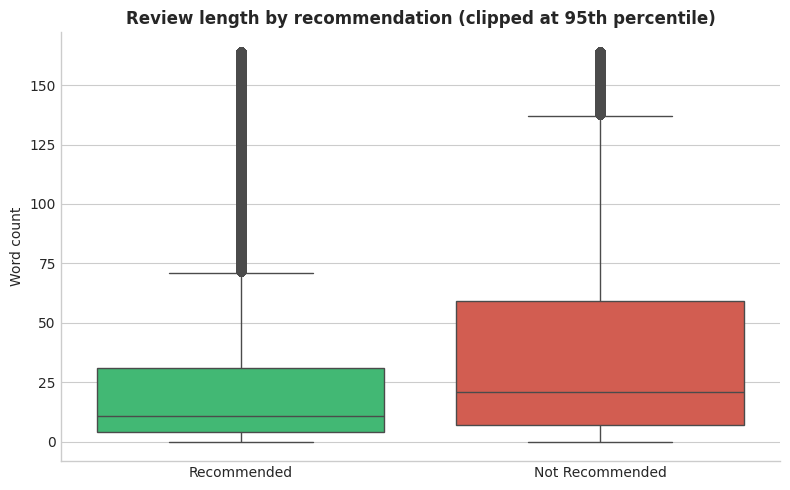

In [12]:
wordcount_by_rec = raw_df.groupby("recommendation")["word_count"].describe().round(1)
display(wordcount_by_rec)

rec_group_wc = raw_df.loc[raw_df["recommendation"] == "Recommended", "word_count"].dropna()
not_rec_group_wc = raw_df.loc[raw_df["recommendation"] == "Not Recommended", "word_count"].dropna()

stat_wc, p_value_wc = mannwhitneyu(rec_group_wc, not_rec_group_wc, alternative="two-sided")
n1_wc, n2_wc = len(rec_group_wc), len(not_rec_group_wc)
rank_biserial_wc = 1 - (2 * stat_wc) / (n1_wc * n2_wc)

display(
    Markdown(
        f"**Mann-Whitney U statistic:** `{stat_wc:,.0f}`  \n"
        f"**p-value:** `{p_value_wc:.4g}`  \n"
        f"**Rank-biserial effect size:** `{rank_biserial_wc:.4f}` "
        f"({'negligible' if abs(rank_biserial_wc) < 0.1 else 'small' if abs(rank_biserial_wc) < 0.3 else 'moderate' if abs(rank_biserial_wc) < 0.5 else 'large'})"
    )
)

plt.figure(figsize=(8, 5))
plot_df_wc = raw_df.copy()
plot_df_wc["word_count_clipped"] = plot_df_wc["word_count"].clip(upper=plot_df_wc["word_count"].quantile(0.95))

ax_wc = sns.boxplot(
    data=plot_df_wc, x="recommendation", y="word_count_clipped",
    hue="recommendation", palette=palette, legend=False,
)
ax_wc.set_title("Review length by recommendation (clipped at 95th percentile)", fontsize=12, fontweight="bold")
ax_wc.set_xlabel("")
ax_wc.set_ylabel("Word count")
sns.despine()
plt.tight_layout()
plt.show()


#### Takeaways
Players who leave a negative review write significantly longer texts (median of 21 words vs 11 words for positive reviews, with a mean nearly double). While the effect size remains small ($r = 0.2201$), it shows that dissatisfied players take more time to explain their frustration, bugs, or technical issues compared to quick positive praise.

## 4.3 Recommendation vs helpfulness votes

`helpful` is a vote count rather than a ratio, ranging from 0 to over 28,000 and heavily dominated by zeros, so much so that the 95th percentile sits at 1.

A standard boxplot clipped at that percentile is unreadable. To address this extreme zero-inflation, the analysis splits into two distinct views:
1. The proportion of reviews receiving zero votes across recommendation types.
2. The vote count distribution among reviews that received at least one vote (analyzed on a log scale).

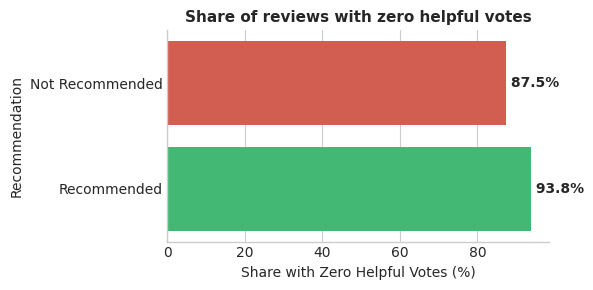

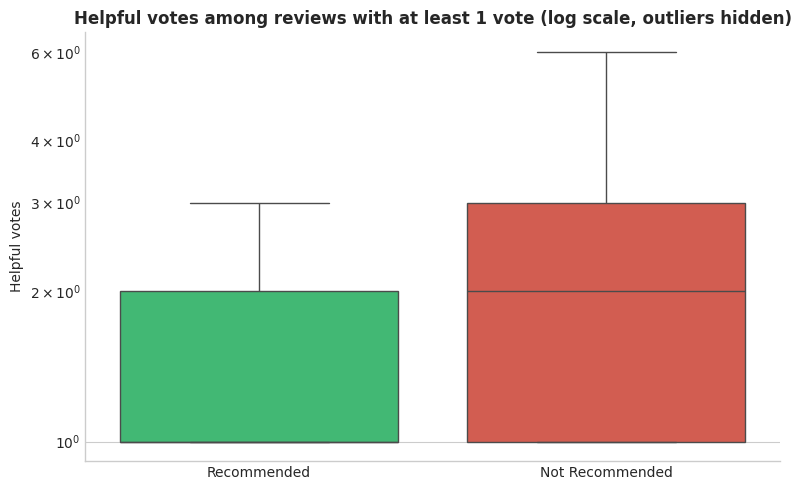

In [13]:
# 1. Simple, readable view: share of reviews with zero helpful votes
zero_helpful_share = (
    raw_df.assign(has_zero_helpful=raw_df["helpful"] == 0)
    .groupby("recommendation")["has_zero_helpful"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)
zero_helpful_share.columns = ["Recommendation", "Share with Zero Helpful Votes (%)"]

plt.figure(figsize=(6, 3))
palette = {"Recommended": "#2ecc71", "Not Recommended": "#e74c3c"}
ax = sns.barplot(
    data=zero_helpful_share, x="Share with Zero Helpful Votes (%)", y="Recommendation",
    hue="Recommendation", palette=palette, legend=False, orient="h",
)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f" {width:.1f}%", (width, p.get_y() + p.get_height() / 2.0),
                ha="left", va="center", fontsize=10, fontweight="bold")
ax.set_title("Share of reviews with zero helpful votes", fontsize=11, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

# 2. Among reviews that DO have at least one helpful vote, compare the distribution
# (removing the zeros makes the comparison actually readable)
voted_df = raw_df[raw_df["helpful"] > 0].copy()

plt.figure(figsize=(8, 5))
ax2 = sns.boxplot(
    data=voted_df, x="recommendation", y="helpful",
    hue="recommendation", palette=palette, legend=False, showfliers=False,
)
ax2.set_yscale("log")
ax2.set_title("Helpful votes among reviews with at least 1 vote (log scale, outliers hidden)", fontsize=12, fontweight="bold")
ax2.set_xlabel("")
ax2.set_ylabel("Helpful votes")
sns.despine()
plt.tight_layout()
plt.show()

### Helpfulness votes

Most reviews get no community interaction at all, but negative ones get more of it. 87.5% of *Not Recommended* reviews have zero votes, against 93.8% of *Recommended* ones.

The gap holds among reviews that do get votes. Negative reviews reach a median of 2 votes with an upper whisker at 6, against a median of 1 and a whisker at 3 for positive ones.

Dissatisfied reviews are not only longer, as section 4.2 showed. They are also read and upvoted more, by players looking for problems before they buy.

## 4.4 Recommendation vs free-product notice

Players who did not pay for a game may evaluate it differently than those who spent money. Whether receiving a review key or promotional copy shifts the verdict is testable rather than assumed, making it useful to cross-tabulate recommendation rates against the free-product flag.

recommendation,Not Recommended,Recommended
Paid for the game,30.5,69.5
Received it free,20.8,79.2


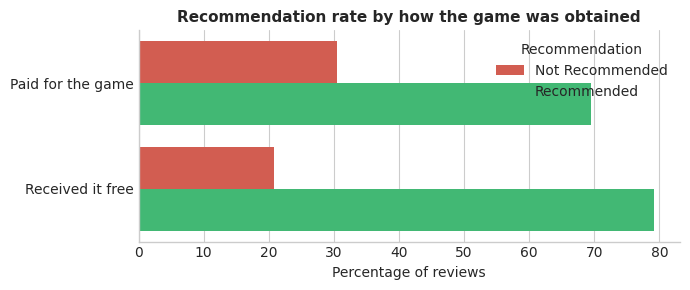

In [14]:
free_mask = raw_df["review"].str.contains("product received for free", case=False, na=False)

crosstab = (
    pd.crosstab(free_mask, raw_df["recommendation"], normalize="index")
    .mul(100).round(1)
)
crosstab.index = ["Paid for the game", "Received it free"]

display(crosstab)

plt.figure(figsize=(7, 3))
plot_data = crosstab.reset_index().melt(
    id_vars="index", var_name="Recommendation", value_name="Percentage"
)
palette = {"Recommended": "#2ecc71", "Not Recommended": "#e74c3c"}
ax = sns.barplot(
    data=plot_data, x="Percentage", y="index",
    hue="Recommendation", palette=palette, orient="h",
)
ax.set_title("Recommendation rate by how the game was obtained", fontsize=11, fontweight="bold")
ax.set_xlabel("Percentage of reviews")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

#### Takeaways
Players who received the game for free are noticeably more forgiving, recommending the game **79.2%** of the time compared to **69.5%** for paying players (a ~10 percentage point increase in positive verdict).

This suggests that financial investment increases player expectations, whereas complimentary copies lead to slightly higher baseline satisfaction.

### Confounding factors in free-product reviews

Two things matter here: the size of the gap, and whether it survives a confound.

The gap itself is about 10 percentage points more positive recommendations among free-product reviews. The question is whether that reflects a real shift in player sentiment.

The confound is text length. Free-product reviews skew heavily towards very short text, as the repeated-text analysis showed, and a two-word "good game" is not the same signal as a considered recommendation.

Telling the two apart needs the length breakdown alongside acquisition status. That means controlling for text length and stripping system-generated prefixes, which belongs to notebook 02 rather than here.

## 7. Export


In [15]:
OUTPUT_PARQUET_PATH = PROCESSED_DIR / "ingested_raw.parquet"
raw_df.to_parquet(OUTPUT_PARQUET_PATH, index=False)

display(
    Markdown(
        f"**Exported** `{OUTPUT_PARQUET_PATH.name}` "
        f"(`{OUTPUT_PARQUET_PATH.stat().st_size / (1024 * 1024):.2f} MB`)  \n"
        f"**Rows:** `{len(raw_df):,}`  \n"
        f"**Columns:** `{list(raw_df.columns)}`"
    )
)


**Exported** `ingested_raw.parquet` (`58.94 MB`)  
**Rows:** `434,891`  
**Columns:** `['date_posted', 'funny', 'helpful', 'hour_played', 'is_early_access_review', 'recommendation', 'review', 'title', 'word_count']`

## Summary

The audit cleared the corpus for modelling and fixed the constraints every later notebook works under: 434,891 reviews across 48 titles, moderately imbalanced at roughly 70% positive, with sound integrity but several structural noise sources to handle in Notebook 02.

### Key numbers at a glance

| Item | Value |
| --- | --- |
| Reviews / titles | 434,891 / 48 (top 4 titles = 88% of volume) |
| Class balance | 69.8% Recommended (303,593) vs 30.2% Not (131,298) |
| Exact row duplicates | 0 |
| Repeated review texts | 54,979 (12.64%) |
| Missing review text | 1,516 (0.35%) |
| Free-product reviews | 15,875 (3.65%), 9.7 points more positive (79.2% vs 69.5%) |
| Length asymmetry | complaints median 21 words vs praise 11 (r = 0.22) |
| Playtime | Recommended reviews sit higher, 207h vs 153h median (r = -0.13) |
| Helpfulness | over 90% of reviews have zero votes |

### Findings and downstream actions

| Observed | Metric | Where it matters | Action in Notebook 02 and beyond |
|---|---|---|---|
| Missing review text | 1,516 rows, 0.35% | Empty tokenisation, model input errors | Drop the rows |
| Exact row duplicates | 0 rows | Data integrity | Keep the check in place for future ingestions |
| Repeated review texts | 54,979 rows, 12.64% | Train/test leakage in NB04, topic inflation in NB05 | Filter by length: keep short generic praise, cut long identical texts to one instance |
| Platform boilerplate prefix | 15,875 reviews, 3.65% | Four metadata tokens ahead of the actual opinion, false topic in NB05 | Strip the prefix, keep the fact as a boolean feature |
| Review bombing | PUBG protest 171 rows, GTA V OpenIV shutdown 134+ rows | One coordinated opinion counted many times | Reduce to one instance each, accept that GTA V variants partly escape |
| Non-textual noise | Invisible Hangul filler read as 89 words, ASCII art | `word_count` overstates substance | Treat word counts as coarse, keep length thresholds loose |
| Class imbalance | 69.81% Recommended vs 30.19% Not Recommended | Metric choice in NB03 and NB04 | Macro F1 over accuracy, class weighting at fine-tuning |
| Title concentration | Top 4 cover 88%, top 6 cover close to 98% | Statistical validity of per-game claims | Restrict per-game topic modelling to the six largest titles |
| Review length asymmetry | Complaints roughly twice as long, median 21 vs 11 words, r = 0.22 | Sequence length choices, richness of NB05 topics | Set padding thresholds accordingly |
| Helpfulness sparsity | Over 90% have zero votes | Whether votes carry any polarity signal | Binarise before use, do not treat raw counts as a sentiment proxy |
| Playtime skew | Median 190 hours; Recommended sit higher, 207h vs 153h, r = -0.13 | Segmenting complaints by player investment | Quantile-based tiers: casual, regular, hardcore |
| Free-product bias | Free reviews are 9.7 points more positive, 79.2% vs 69.5% | Confound between incentive and brevity | Control for text length alongside the free-product flag |

### Open questions

Does the higher recommendation rate among free-product reviews reflect genuine satisfaction, or is it an artifact of short low-effort text? The two explanations are not separable from what this notebook measured.

Does playtime separate complaints from praise more clearly within individual games than across the pooled corpus? A survival game and a competitive shooter have nothing comparable in playtime terms, so the pooled effect size of 0.13 may be hiding stronger per-game patterns. Notebook 05 tests this directly.